## CENTROID EVOLUTION
Two methods are implemented to study the centroid evolution: RSS and STD. Full description at 'comparison of beam positioncalculation methods for application in digital acquisition systems', A Reiter, R Singh https://www.sciencedirect.com/science/article/pii/S0168900218302006 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from tools.frequency_finder import main_frequency
from tools.open_h5 import print_tree, open_file

In [2]:
file = '/Volumes/RFS/Wakes and Space Charge/cern/sps/2018_10_TMCImeasurements/headtail/2018_11_09/SPS.BQHT_MD4_20181109_000915.h5'

In [3]:
print_tree(file)

|-- horizontal
  |-- delta
  |-- sigma
|-- vertical
  |-- delta
  |-- sigma


In [4]:
vert_delta, vert_sigma, horiz_delta, horiz_sigma = open_file(file)

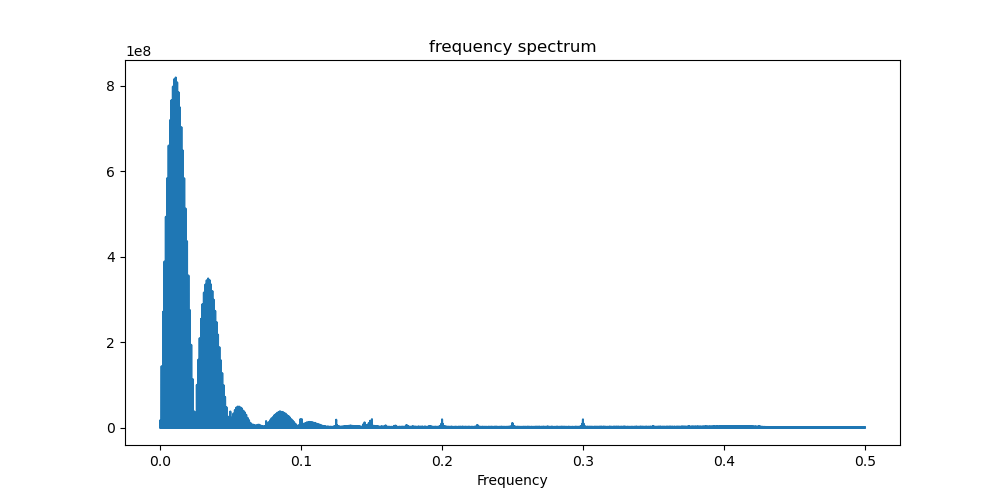

5000001


In [5]:
%matplotlib widget
plt.figure(figsize=(10,5))
plt.plot(np.fft.rfftfreq(len(vert_sigma)),np.abs(np.fft.rfft(vert_sigma-np.mean(vert_sigma))))
plt.title('frequency spectrum')
plt.xlabel('Frequency')
plt.show()

print(len(np.fft.rfft(vert_sigma-np.mean(vert_sigma))))

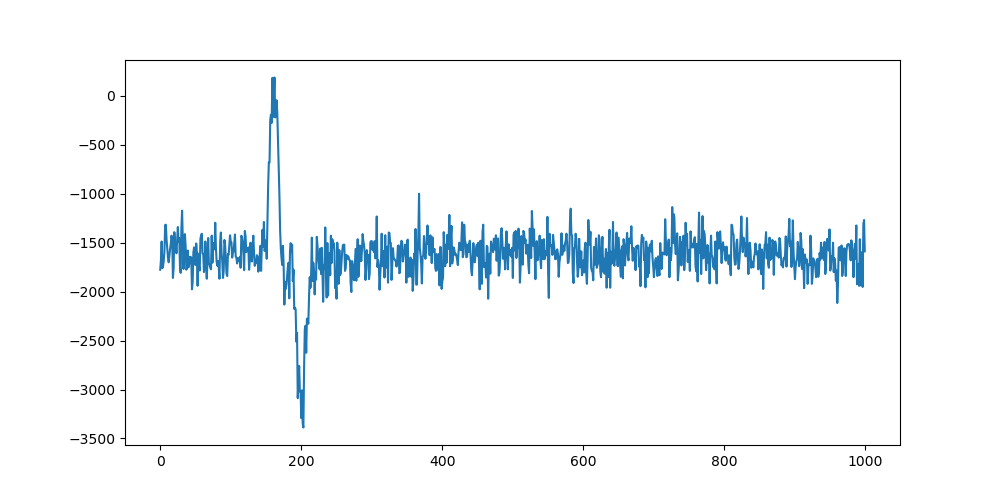

In [6]:
%matplotlib widget
plt.figure(figsize=(10,5))
plt.plot(vert_delta[100000:101000])
plt.show()

## RSS METHOD

In [ ]:
from tools.centroid_motion import rss_positi#on_from_delta_sigma

In [8]:
x_centroid, sigma_x_c = rss_position_from_delta_sigma(vert_delta, vert_sigma, 0.02, 100,loops=10000,period=1000)

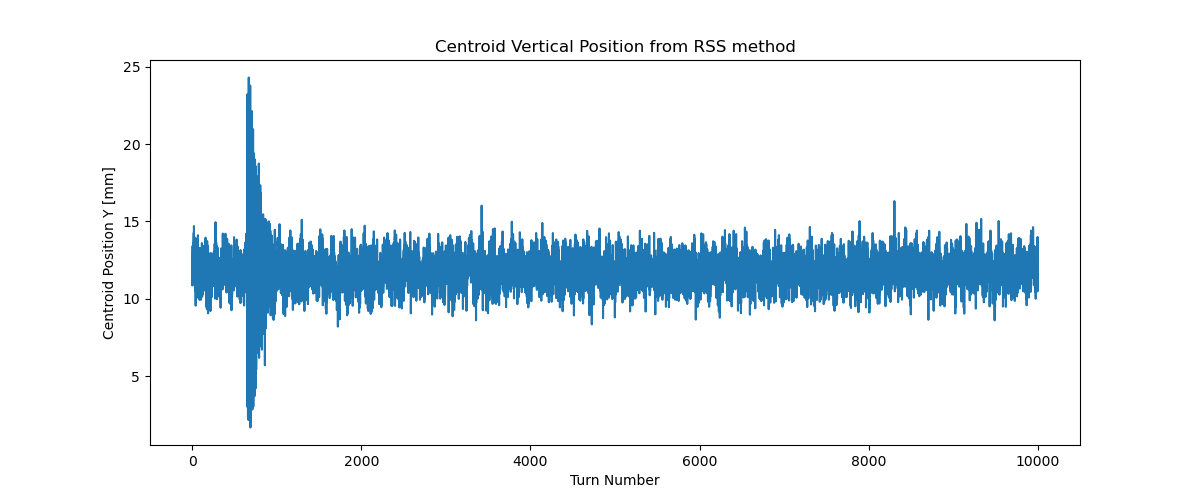

In [9]:
%matplotlib widget
plt.figure(figsize=(12,5))
plt.plot(x_centroid)
plt.title('Centroid Vertical Position from RSS method')
plt.xlabel('Turn Number')
plt.ylabel('Centroid Position Y [mm]')
plt.show()

In [10]:
# %matplotlib widget
# plt.figure(figsize=(18,5))
# plt.plot(sigma_x_c)

## STANDARD DEVIATION METHOD

In [11]:
from tools.centroid_motion import std_position_from_delta_sigma

In [12]:
x_STD, sigma_x_s = std_position_from_delta_sigma(vert_delta, vert_sigma, 0.02, 100,loops=10000,period=1000)

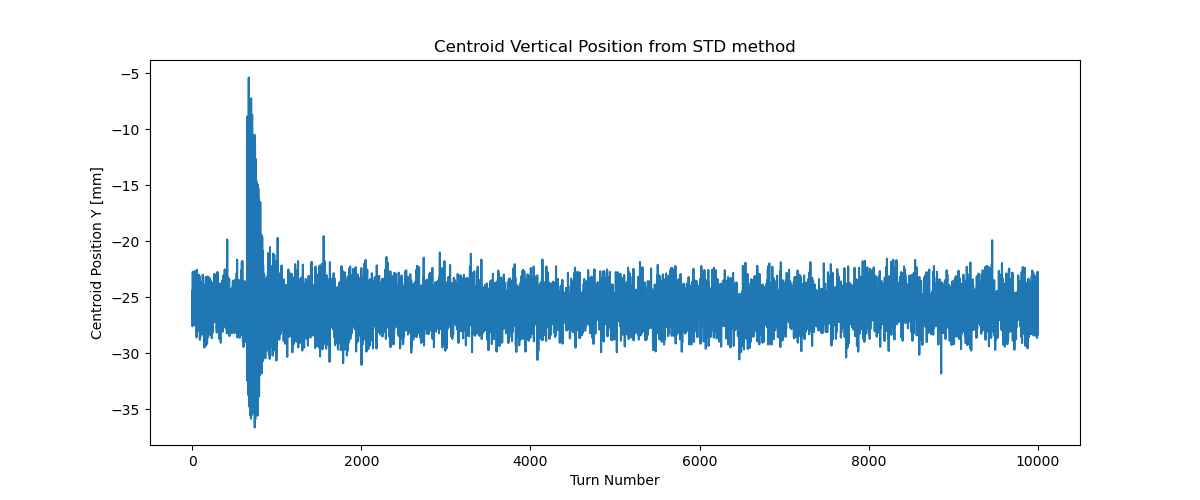

In [13]:
%matplotlib widget
plt.figure(figsize=(12,5))
plt.title('Centroid Vertical Position from STD method')
plt.xlabel('Turn Number')
plt.ylabel('Centroid Position Y [mm]')
plt.plot(x_STD)